Optimal parameters (MLE):
  Ymax  = 3.80 %
  c0    = 44.0 mM
  w     = 29.0 mM
  sigma = 0.20 %
  NLL   = -1.897


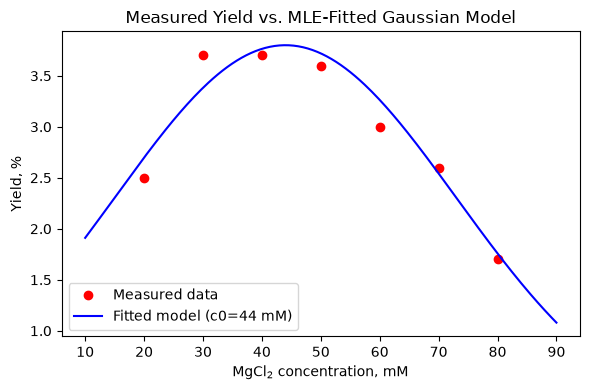

Curvature: c0_hat = 44.0 +/- 1.3 mM
Bootstrap: c0_hat = 44.0 +/- 3.3 mM (bootstrap SD)


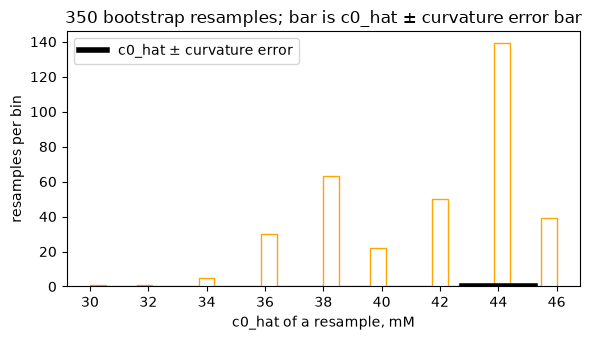

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

### ---------- Data ---------- ###

conc = np.array([20, 30, 40, 50, 60, 70, 80], dtype=float)
yield_perc = [2.5, 3.7, 3.7, 3.6, 3.0, 2.6, 1.7]

# plt.figure(figsize=(6, 4))
# plt.plot(conc, yield_perc, 'o-', color='red')
# plt.xlabel("MgCl$_2$ concentration, mM")
# plt.ylabel("Yield, %")
# plt.title("Yield vs. [MgCl$_2$]")
# plt.tight_layout()
# plt.show()

### ---------- Random number generator ---------- ###

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m

def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out


### ---------- Gaussian model ---------- ###

def Gaussian(c, theta):
    """Predicted mean yield at concentration c. theta = (Ymax, c0, w)."""
    Ymax, c0, w = theta
    return Ymax * np.exp(-((c - c0)**2) / (2*w**2))


### ---------- Density ---------- ###

def normal(x, mu, sigma):
    """f(x | mu, sigma)."""
    density = math.exp(-(x-mu)**2 / (2*sigma**2)) / (sigma * (2*math.pi)**0.5)
    return max(density, 1e-300)


### ---------- NLL ---------- ###

def nll(conc, yields, theta):
    """theta = (Ymax, c0, w, sigma)."""
    Ymax, c0, w, sigma = theta
    total = 0.0
    for c, y in zip(conc, yields):
        mu = Gaussian(c, (Ymax, c0, w))
        total -= math.log(normal(y, mu, sigma))
    return total


### ---------- Maximum-Likelihood Method (backward simulation) ---------- ###

def position_of_min(values):
    """Smallest value"""
    best = 0
    for j in range(len(values)):
        if values[j] < values[best]:
            best = j
    return best

def fit_grid(conc_sample, yield_sample):
    """Grid-search MLE fit"""
    candidates = []
    scores = []
    for Ymax in np.arange(2.0, 6.0, 0.2):
        for c0 in np.arange(10, 80, 2.0):
            for w in np.arange(5, 40, 2.0):
                for sigma in np.arange(0.05, 0.6, 0.05):
                    theta = (Ymax, c0, w, sigma)
                    candidates.append(theta)
                    scores.append(nll(conc_sample, yield_sample, theta))
    return candidates[position_of_min(scores)]

theta_hat = fit_grid(conc, yield_perc)
Ymax_hat, c0_hat, w_hat, sigma_hat = theta_hat
best_nll = nll(conc, yield_perc, theta_hat)

print(f"Optimal parameters (MLE):")
print(f"  Ymax  = {Ymax_hat:.2f} %")
print(f"  c0    = {c0_hat:.1f} mM")
print(f"  w     = {w_hat:.1f} mM")
print(f"  sigma = {sigma_hat:.2f} %")
print(f"  NLL   = {best_nll:.3f}")


### ---------- Plot: measured data vs. fitted model ---------- ###

c_smooth = np.linspace(10, 90, 200)
y_fit = Gaussian(c_smooth, (Ymax_hat, c0_hat, w_hat))

plt.figure(figsize=(6, 4))
plt.plot(conc, yield_perc, "o", color="red", label="Measured data")
plt.plot(c_smooth, y_fit, "-", color="blue", label=f"Fitted model (c0={c0_hat:.0f} mM)")
plt.xlabel("MgCl$_2$ concentration, mM")
plt.ylabel("Yield, %")
plt.title("Measured Yield vs. MLE-Fitted Gaussian Model")
plt.legend()
plt.tight_layout()
plt.show()


### ---------- Curvature-based uncertainty on c0 ---------- ###

h = 0.5
curvature = (nll(conc, yield_perc, (Ymax_hat, c0_hat + h, w_hat, sigma_hat))
             - 2 * nll(conc, yield_perc, (Ymax_hat, c0_hat, w_hat, sigma_hat))
             + nll(conc, yield_perc, (Ymax_hat, c0_hat - h, w_hat, sigma_hat))) / h ** 2

sigma_c0 = 1 / curvature ** 0.5
print(f"Curvature: c0_hat = {c0_hat:.1f} +/- {sigma_c0:.1f} mM")


### ---------- Bootstrap ---------- ###

N = len(conc)
B = 350
SEED = 8
rs = uniforms(B * N, SEED)
equal = [1 / N] * N

def choose(r, probs):
    running = 0.0
    for k in range(len(probs)):
        running += probs[k]
        if r < running:
            return k
    return len(probs) - 1

boot_c0 = [0.0] * B
boot_Ymax = [0.0] * B

for b in range(B):
    conc_resample = [0.0] * N
    yield_resample = [0.0] * N
    for i in range(N):
        j = choose(rs[b*N + i], equal)
        conc_resample[i] = conc[j]
        yield_resample[i] = yield_perc[j]

    theta_b = fit_grid(conc_resample, yield_resample)
    boot_Ymax[b], boot_c0[b], w_b, sigma_b = theta_b

sigma_c0_boot = np.std(boot_c0)
print(f"Bootstrap: c0_hat = {c0_hat:.1f} +/- {sigma_c0_boot:.1f} mM (bootstrap SD)")


### ---------- Plot of the bootstrap distribution of c0 ---------- ###

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(boot_c0, bins=30, color="orange", histtype="step")
ax.plot([c0_hat - sigma_c0, c0_hat + sigma_c0], [0, 0], color="black", linewidth=4,
        label="c0_hat ± curvature error")
ax.set_xlabel("c0_hat of a resample, mM")
ax.set_ylabel("resamples per bin")
ax.set_title(f"{B} bootstrap resamples; bar is c0_hat ± curvature error bar")
ax.legend()
plt.tight_layout()
plt.show()